# 🏒 Hockey Pythagoras Estimate
### Learning and Understanding the Hockey Pythagoras Estimate
*Data from MoneyPuck.com and Hockey-Reference, and Method from [Stapled To The Bench](https://www.stapledtothebench.com/wp-content/uploads/2024/12/2024-12-Hockey-Pythagoras-Estimate.pdf)*

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np


print("Libraries loaded successfully!")

Libraries loaded successfully!


## Data Cleainng

We will first need to clean and restructure our datasets, so they work with each other rather than against each other!

We are going to start by creatig consistent formatting for season data, then we will need to standardize team names and drop any extranous data columns. While we are cleaning team names, we will refer to all future and past seasons of the Arizona Coyotes as "UTA"

In [108]:
df_f = pd.read_csv("teams_2008_to_2024.csv")
df_f['season'] = df_f['season'].apply(lambda x: f"{x}-{str(x+1)[-2:]}")

df_f = df_f[df_f["situation"] == "all"]

df_f.loc[df_f['team'] == 'ARI', 'team'] = 'UTA'
df_f.loc[df_f['team'] == 'L.A', 'team'] = 'LAK'
df_f.loc[df_f['team'] == 'T.B', 'team'] = 'TBL'
df_f.loc[df_f['team'] == 'ATL', 'team'] = 'WPG'
df_f.loc[df_f['team'] == 'S.J', 'team'] = 'SJS'
df_f.loc[df_f['team'] == 'N.J', 'team'] = 'NJD'
df_f.loc[df_f['team'] == 'VGK', 'team'] = 'VEG'

df_f = df_f.drop(columns=['team.1', 'name', 'position', 'situation'])
df_f.head(5)


df_f['season'].describe()


count         522
unique         17
top       2024-25
freq           32
Name: season, dtype: object

The data gathered for past point counts, seperated past UTA scores (as they were under the name Arizona Coyotes) so, we need to merge the two points database. Then we need to "flip" the database to match the formating of the final HPE dataset.

In [111]:
df_pts = pd.read_csv("pts_uta.csv")

df_pts = df_pts[(df_pts["Season"] != '2025-26') & (df_pts["Season"] >= '2008-09')]
df_pts = df_pts.rename(columns={"Season":"season"})
df_pts = df_pts.drop(columns=['Rk','Lg'])

df_pts_long = df_pts.melt(id_vars='season', var_name='team', value_name='pts')
df_pts_long = df_pts_long.dropna()

Now, we will combine both datasets!

In [114]:
df_pts = df_f.merge(df_pts_long, on=['team', 'season'], how='left')
df_pts.head(5)[['team','season', 'pts']]

,team,season,pts
0,MIN,2008-09,89.0
1,BOS,2008-09,116.0
2,UTA,2008-09,79.0
3,LAK,2008-09,79.0
4,COL,2008-09,69.0


## Calculating Hockey Pythagoras Estimate

We will calculate HPE using the stapled benches provided formula.

In [118]:
def calculate_hpe(row):
    WHPE = round(82 * (row['goalsFor'] ** 2) / ( (row['goalsFor'] ** 2 ) + (row['goalsAgainst'] ** 2) ))
    
    THPE = round(WHPE * 0.22)
    
    LHPE = 82-WHPE-THPE
    
    return WHPE, LHPE, THPE

In [120]:
def calculate_pts(row):
    WHPE, LHPE, THPE = row['p_WLO']
    
    pts = (2 * WHPE) + THPE
    
    return pts    

We will need to filter out both the lockout shortened schedule and the covid shortened schedule, as HPE is based on a 82 game schedule.

In [123]:
df_HPE = df_pts[(df_pts["season"] != "2020-21") & (df_pts['season'] != "2012-13") & (df_pts['season'] != '2019-20')].copy()
df_HPE['p_WLO'] = df_HPE.apply(calculate_hpe, axis=1)
df_HPE['p_pts'] = df_HPE.apply(calculate_pts, axis=1)


df_HPE[['season','team','p_WLO', 'p_pts', 'pts']].head(5)

,season,team,p_WLO,p_pts,pts
0,2008-09,MIN,"(44, 28, 10)",98,89.0
1,2008-09,BOS,"(55, 15, 12)",122,116.0
2,2008-09,UTA,"(32, 43, 7)",71,79.0
3,2008-09,LAK,"(36, 38, 8)",80,79.0
4,2008-09,COL,"(30, 45, 7)",67,69.0


## Results and Discussion

Now, lets take a closer look at our difference between the predicted points (HPE) and the actual points each team got for each season.

Text(0.5, 1.0, 'Actual Points vs Predicted')

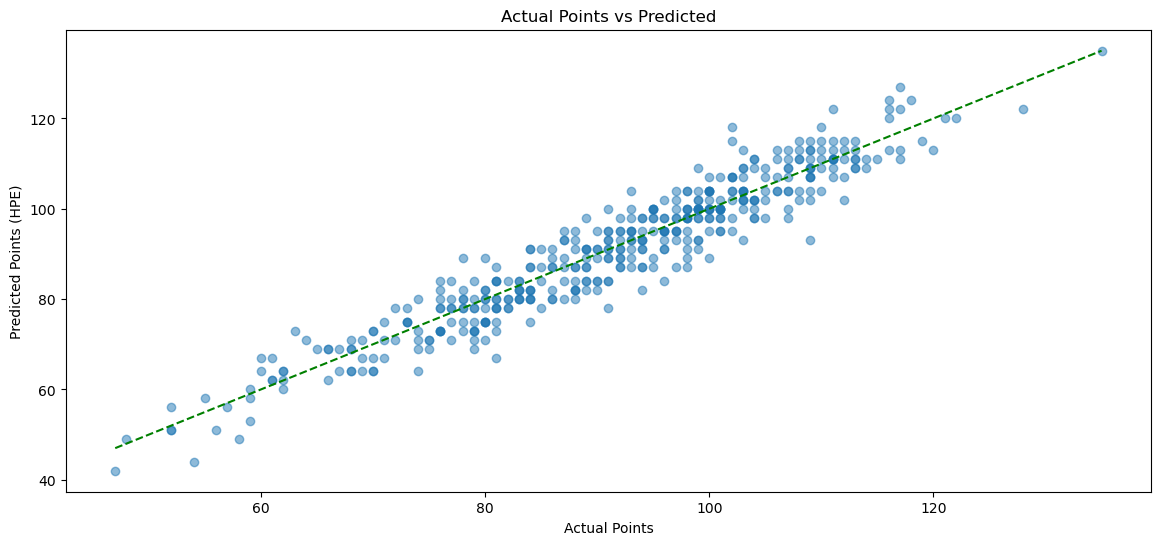

In [127]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

axes.scatter(df_HPE['pts'], df_HPE['p_pts'], alpha=0.5)

min_val = df_HPE['pts'].min()
max_val = df_HPE['pts'].max()
axes.plot([min_val, max_val], [min_val, max_val], color='green', linestyle='--', label='Perfect Prediction')

axes.set_xlabel('Actual Points')
axes.set_ylabel('Predicted Points (HPE)')
axes.set_title('Actual Points vs Predicted')

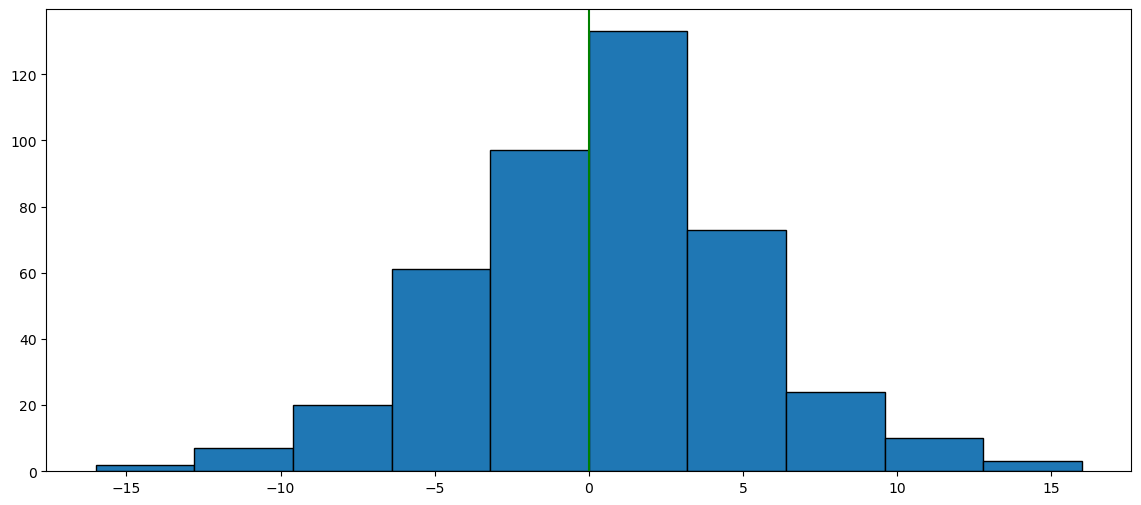

In [129]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

df_HPE['residual'] = df_HPE['pts'] - df_HPE['p_pts']
axes.hist(df_HPE['residual'], bins=10, edgecolor='black')
axes.axvline(x=0, color='green', linestyle='-', label='Zero Error')


In [168]:
within_four = (df_HPE['residual'].abs() <= 4).sum()
total = len(df_HPE)
percentage = (within_four / total) * 100

print(f"HPE is within four standing points {percentage:.1f}% of the time")

HPE is within four standing points 64.4% of the time


In [170]:
df_HPE['pts'].sum()

39316.0

In [172]:
df_HPE['p_pts'].sum()

39164

In [174]:
39164/39316  * 100

99.61338895106317

## Summary + Learning Outcomes

Across our 17 seasons (2007-08 to 2024-25, excluding the shortened lockout and covid seasons), HPE predicted 39,164 total points vs 39,316 actual points (~99.6% of actual). Our model predicts within four standing points of actual 64.4% of the time, compared to the guide's 68.5%. This gap may reflect our additional seasons of data introducing more variance. By understanding HPE, we can better evaluate whether a team is over or underperforming relative to their goal differential. Future iterations, would work on closing the gap between predicted and actual, less overpredicting.